# Solving Richards' Equation — 1D Infiltration

**MOOC "The Hydrology of Soil" — Chapter 5, Episodes 05x02–05x03**

---

In Chapter 4 we arrived at **Richards' equation**. This notebook is the
companion to the lessons on **solving** it: it contains a small but complete
**1-D finite-volume solver** for vertical infiltration, so that students can

1. run the classic numerical experiment — **ponded infiltration into a dry
   soil column** — and watch the wetting front advance;
2. change the **boundary conditions** (ponding depth, free drainage vs.
   impervious bottom) and the **soil type**, and see the effect;
3. check **mass conservation** — the property a good Richards solver must have;
4. appreciate *why* the equation is hard: the strongly nonlinear hydraulic
   capacity.

The solver uses the **mixed-form, modified-Picard** scheme of
**Celia, Bouloutas & Zarba (1990)** — the canonical mass-conservative method,
and the natural lead-in to the nested-Newton method of Casulli & Zanolli (2010)
used in WHETGEO.

Run the cells in order (Shift+Enter). The solver is plain NumPy — no special
packages required.


## 0 — Setup

In [2]:
try:
    from soil_course import *
    print("soil_course already available")
except ModuleNotFoundError:
    !pip install git+https://github.com/panzerotto/soil_course.git
    from soil_course import *

print("Setup complete")


  Cloning https://github.com/panzerotto/soil_course.git to /tmp/pip-req-build-29eyolfo
  Running command git clone --filter=blob:none --quiet https://github.com/panzerotto/soil_course.git /tmp/pip-req-build-29eyolfo
  Resolved https://github.com/panzerotto/soil_course.git to commit 49cf79ec0e5c26a07c447252bfe2793f4f411cc1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for soil-course: filename=soil_course-0.1.0-py3-none-any.whl size=25754 sha256=70d77e7090823310ca2d2b56edf3b8078a5594c4a3dbbba3eca7e4990baa5f7a
  Stored in directory: /tmp/pip-ephem-wheel-cache-_1wsu0qh/wheels/d1/cc/3a/6e11e3051820dbb8642dabb07e7fbe97d50387e4b7f07545bd
Successfully built soil-course
Setup complete


## 1 — The constitutive relations (van Genuchten–Mualem)

Richards' equation needs two closures (Chapters 2–3): the retention curve
θ(ψ) and the conductivity K(ψ). We use van Genuchten–Mualem. Suctions are
handled through the **pressure head** ψ (cm); ψ < 0 is unsaturated, ψ ≥ 0 is
saturated.

The **hydraulic capacity** C(ψ) = dθ/dψ also appears — it multiplies the time
derivative in the head-based form, and its strong peak near ψ = 0 is the source
of the numerical difficulty.


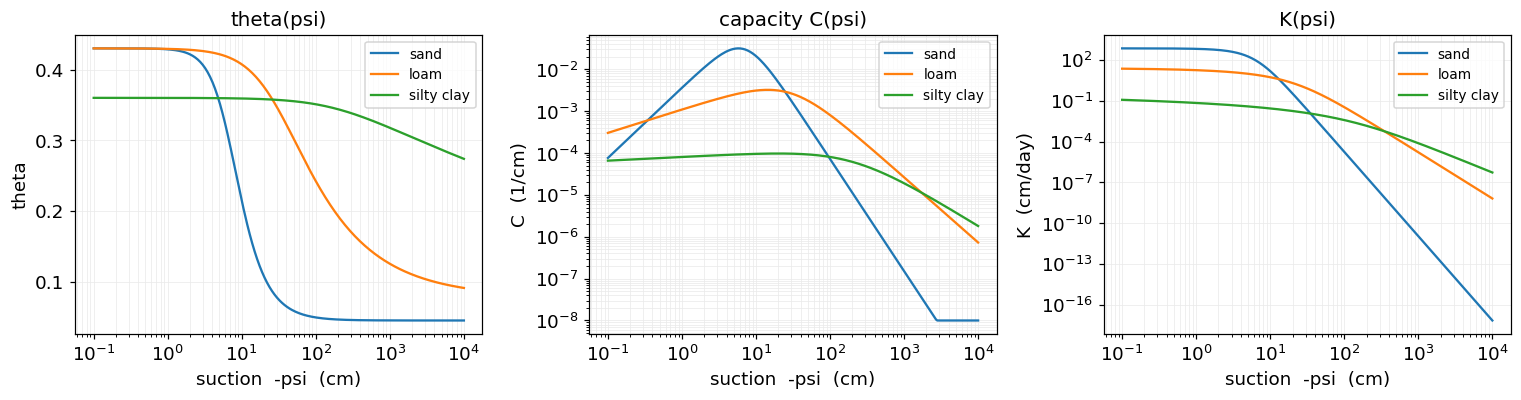

In [3]:
plot_richards_constitutive_relations()


Notice the **middle panel**: the capacity C(ψ) is sharply peaked. A numerical
scheme that is not built carefully will lose or gain water exactly where this
peak sits — which is the whole point of the Celia et al. (1990) mixed form.


## 2 — The solver

We solve the **mixed form** of Richards' equation for vertical infiltration,
with depth $z$ pointing **downward** from the surface:

$$\frac{\partial \theta}{\partial t}
   = \frac{\partial}{\partial z}\!\left[K(\psi)\left(\frac{\partial \psi}{\partial z} - 1\right)\right].$$

Discretisation: **cell-centred finite volumes** in space, **implicit (backward)
Euler** in time, and the **modified-Picard iteration** of Celia et al. — the
storage term is expanded as
$\theta^{m+1} \approx \theta^{m} + C^{m}\,(\psi^{m+1}-\psi^{m})$,
which keeps the scheme **mass-conservative** regardless of time-step size.

Each iteration solves a tridiagonal linear system (Thomas algorithm).


In [4]:
# The full finite-volume modified-Picard solver is hidden inside the package.
# You can still call it directly if needed:
# out = solve_richards(SOILS_RICHARDS["loam"], t_end=1.0)

print("Richards solver available: solve_richards(...)")


Richards solver available: solve_richards(...)


## 3 — The classic experiment: ponded infiltration into dry soil

We pond a thin layer of water on the surface (`psi_top = 0`, i.e. the surface
is just saturated) of an initially **dry** column and watch the **wetting
front** move downward. This is the standard test problem of Celia et al. (1990).


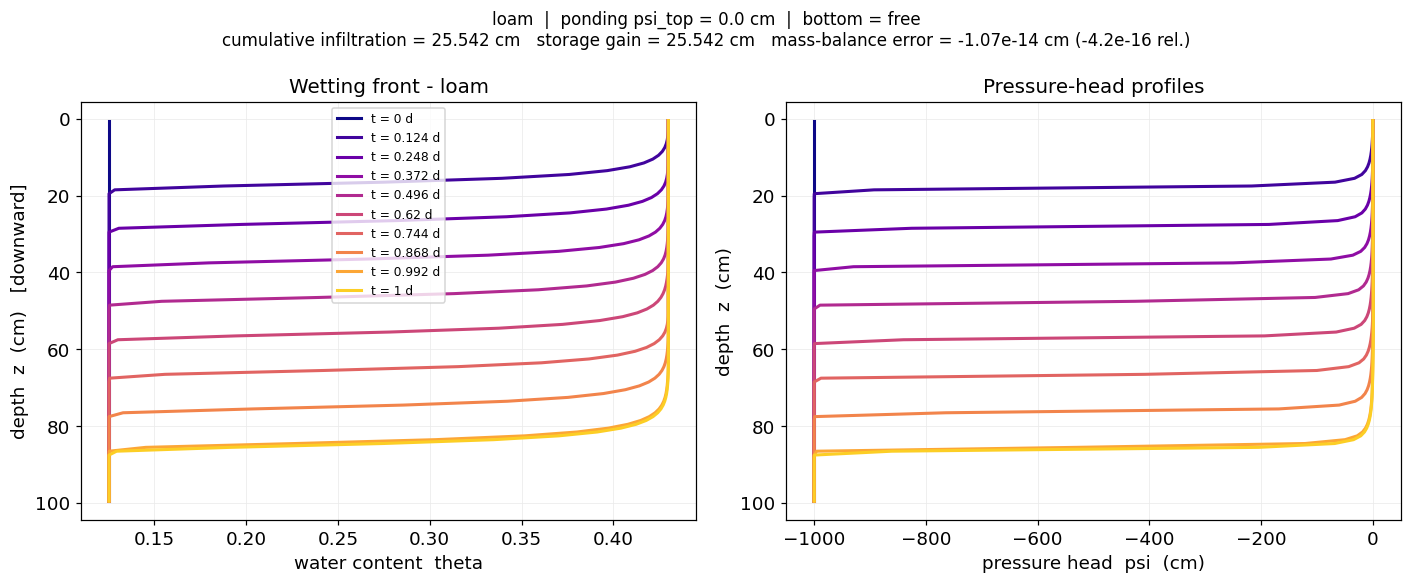

In [5]:
out = plot_infiltration("loam", t_end=1.0)


The **mass-balance error** printed in the title should be tiny (of the order
of $10^{-3}$ cm or smaller) — that is the property the modified-Picard /
mixed-form scheme is designed to guarantee. A naive head-based scheme would
show a much larger error here.


## 4 — Interactive: change the experiment

Move the controls and re-run:

* **soil** — sand drains fast, silty clay barely moves;
* **ponding** `psi_top` — 0 cm = just-saturated surface; a positive value is a
  real ponded water depth;
* **initial dryness** `psi_init` — how dry the column starts;
* **bottom** — *free* drainage lets water leave; *imperv* traps it.

> Without `ipywidgets`, call `plot_infiltration(...)` directly.


In [8]:
interactive_infiltration()


interactive(children=(Dropdown(description='soil', index=1, options=('sand', 'loam', 'silty clay'), value='loa…

## 5 — Why the time step matters

Richards' equation is nonlinear: the modified-Picard iteration must converge
at every step. Too large a time step and the wetting front is smeared or the
iteration struggles; too small and the run is slow. The cell below runs the
same problem at several time steps and overlays the final profiles.


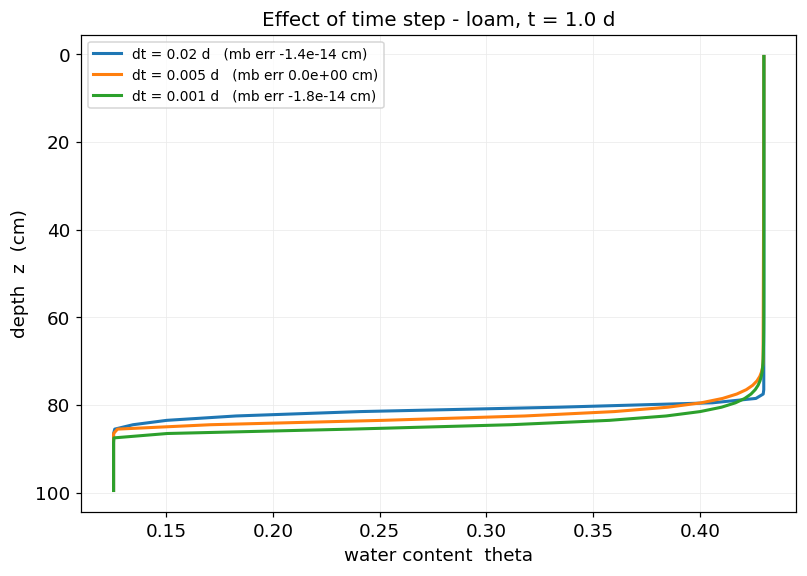

In [7]:
time_step_study("loam")


## Exercises

1. **Front speed and soil type.** Run the same `t_end` for sand, loam and silty
   clay. Rank them by how deep the wetting front travels. Relate this to the Ks
   values in `SOILS`.

2. **Ponding depth.** For a loam, compare `psi_top = 0` and `psi_top = 10` cm.
   Does ten centimetres of standing water make a large difference to how much
   water has infiltrated after one day?

3. **Free vs impervious bottom.** Run a loam column for 3 days with `bottom =
   'free'` and again with `bottom = 'imperv'`. In the impervious case, what
   happens to the pressure head at the base, and why?

4. **Mass balance.** Read the mass-balance error in the title for each run.
   Is it always small? Increase `dt` to 0.05 d — does the error grow? This is
   the practical meaning of "mass-conservative scheme".

5. **The dry-soil difficulty.** Set `psi_init = -5000` cm (very dry) for a
   silty clay. The wetting front becomes very sharp. Explain, using the
   capacity plot of Section 1, why a sharp front is numerically demanding —
   and why this motivates the nested-Newton method of Casulli & Zanolli used in
   WHETGEO.

---

*Companion to the MOOC "The Hydrology of Soil", Chapter 5, Episodes 05x02-03 —
Solving Richards' Equation. Scheme: mixed-form modified Picard
(Celia, Bouloutas & Zarba 1990). Licensed CC BY-SA, consistent with the
lecture slides.*
